In [1]:
#Import all the necessary modules
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
df = pd.read_csv('Bank_Personal_Loan_Modelling.csv')

In [3]:
df.sample(5)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
3026,3027,44,20,81,90254,4,0.8,1,228,0,0,0,0,1
2047,2048,63,38,134,90640,3,4.0,2,0,1,0,0,0,1
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
2552,2553,39,15,65,95822,1,1.5,3,0,0,0,0,0,0
651,652,28,4,58,92121,3,1.5,1,131,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


### Studying the Data distribution

In [6]:
#analyze the distribution of the various attributes
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000002081C8FEA58>,
      dtype=object)

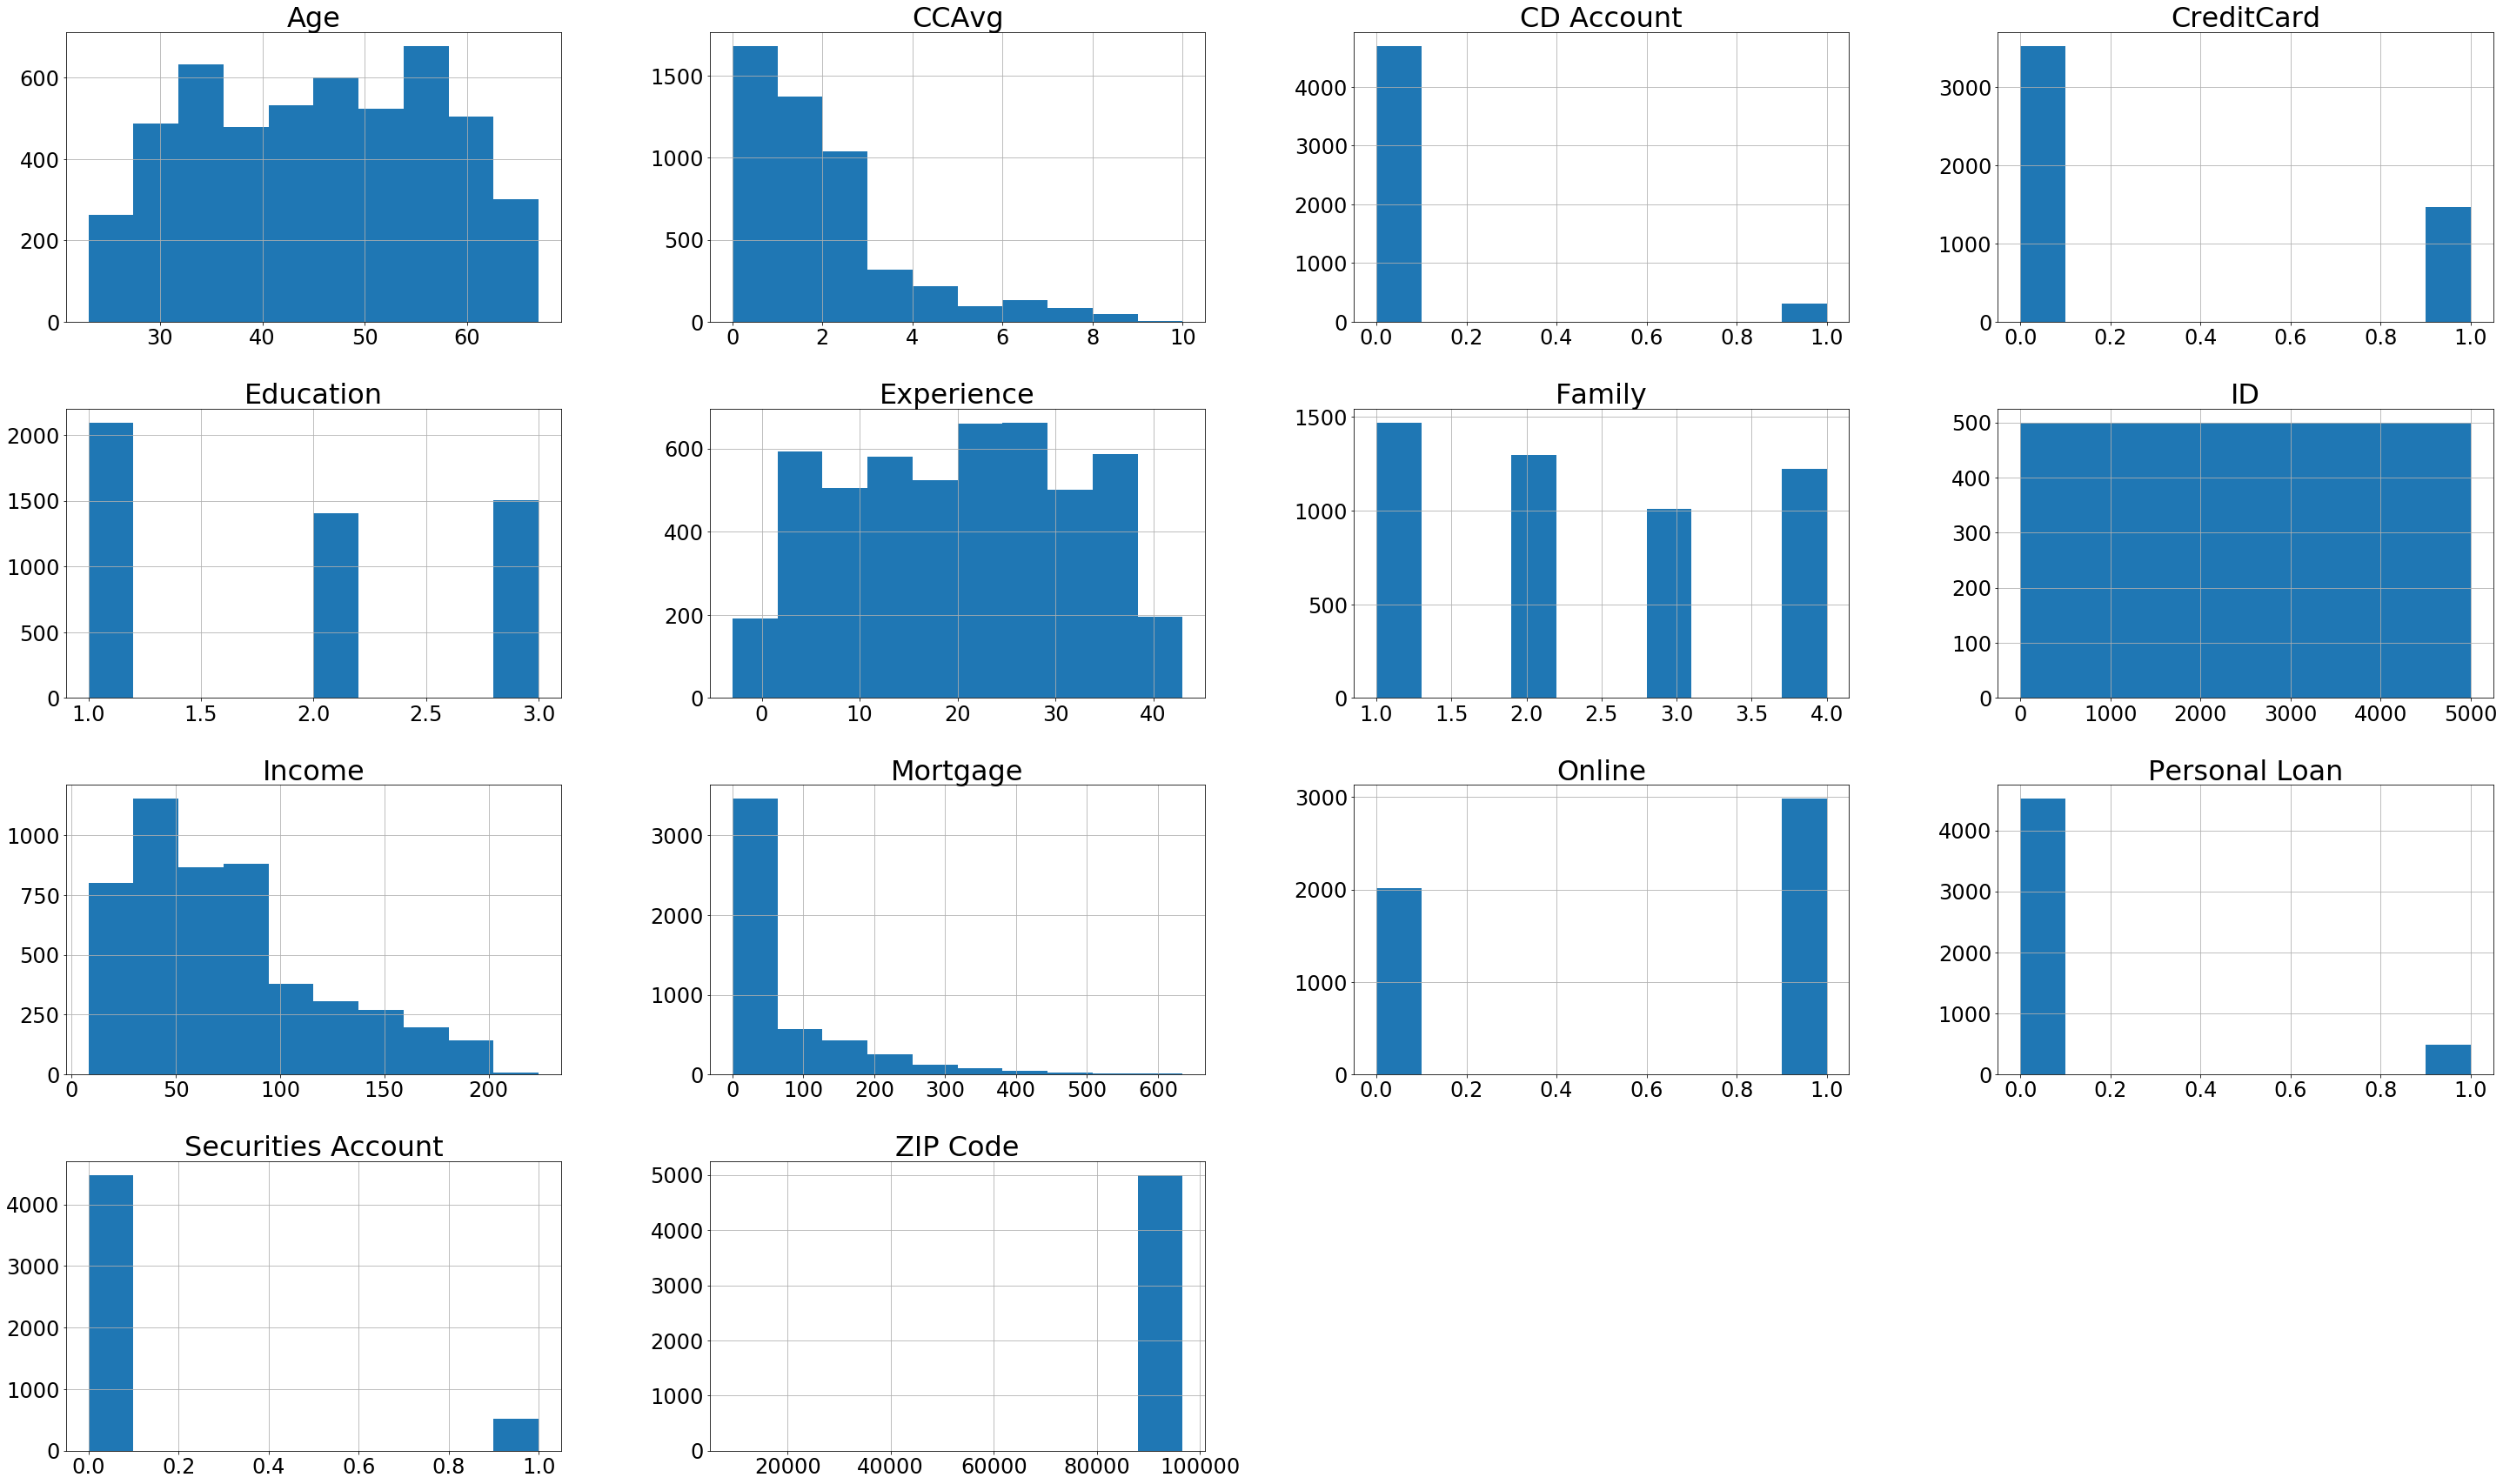

In [8]:
# importing ploting libraries
import matplotlib.pyplot as plt   
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 
params = {'axes.titlesize':'32',
          'xtick.labelsize':'24',
          'ytick.labelsize':'24'}
plt.rcParams.update(params)
df.hist(figsize=(50, 30))

In [9]:
## Observations / Findings
# Average Age of the customers is around 45 years
# Average Experience of customer is around 20 years
# Majority of the customers do not have existing loans like Mortgage, Personal Loan
# Majority of the customers do not have Securities Account, CD Account with the bank
# Majority of the customers do not have Credit Card
# Average Income of the Customers is 73 (as the unit is not specified in the problem or dataset, hence assuming in $1000s)
# Close to 40% of customers Do Not use Online Banking facilities.

### Target column distribution

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000002081AFA8940>]],
      dtype=object)

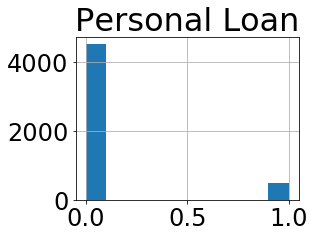

In [10]:
df[['Personal Loan']].hist(figsize=(4, 3))

In [24]:
(df['Personal Loan']>0).sum()

480

In [11]:
## Observation / Finding
# Roughly 10% of customers (9.6% to be precise) have accepted the Personal Loan offered during earlier campaign.

### Split data into train and test

In [12]:
X = df.drop("Personal Loan", axis=1)
y = df["Personal Loan"]

In [13]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Apply various classification models (Logistic, KNN, Naive-Bayes), check accuracy and print confusion matrix

In [14]:
# Logistic Regression Model
lrmodel = LogisticRegression()
lrmodel.fit(X_train,y_train)
y_predict = lrmodel.predict(X_test)
lrmodel_accuracy = accuracy_score(y_test, y_predict)
print('Logistic Model Accuracy -',lrmodel_accuracy)

Logistic Model Accuracy - 0.9153333333333333


In [15]:
# Confusion Matrix for Logistic Regression model
metrics.confusion_matrix(y_test, y_predict)

array([[1332,   30],
       [  97,   41]], dtype=int64)

In [16]:
tn, fp, fn, tp = confusion_matrix(y_test, y_predict).ravel()
resultsDf = pd.DataFrame({'Model':[],'Accuracy':[],'True-Positive':[],'True-Negative':[],'False-Positive':[],'False-Negative':[]})
resultsDf = resultsDf.append({'Model':'Logistic Regression','Accuracy':lrmodel_accuracy,'True-Positive':tp,'True-Negative':tn,'False-Positive':fp,'False-Negative':fn}, ignore_index=True)

In [17]:
# KNN Model
knnmodel = KNeighborsClassifier(n_neighbors= 5)
knnmodel.fit(X_train,y_train)
y_predict = knnmodel.predict(X_test)
knnmodel_accuracy = accuracy_score(y_test, y_predict)
print('KNN Model Accuracy -',knnmodel_accuracy)

KNN Model Accuracy - 0.908


In [18]:
# Confusion Matrix for KNN model
metrics.confusion_matrix(y_test, y_predict)

array([[1358,    4],
       [ 134,    4]], dtype=int64)

In [19]:
tn, fp, fn, tp = confusion_matrix(y_test, y_predict).ravel()
resultsDf = resultsDf.append({'Model':'KNN','Accuracy':knnmodel_accuracy,'True-Positive':tp,'True-Negative':tn,'False-Positive':fp,'False-Negative':fn}, ignore_index=True)

In [20]:
# Naive Bayes Model
nbmodel = GaussianNB()
nbmodel.fit(X_train, y_train)
y_predict = nbmodel.predict(X_test)
nbmodel_accuracy = accuracy_score(y_test, y_predict)
print('Naive Bayes Model Accuracy -',nbmodel_accuracy)

Naive Bayes Model Accuracy - 0.8786666666666667


In [21]:
# Confusion Matrix for Naive Bayes model
metrics.confusion_matrix(y_test, y_predict)

array([[1237,  125],
       [  57,   81]], dtype=int64)

In [22]:
tn, fp, fn, tp = confusion_matrix(y_test, y_predict).ravel()
resultsDf = resultsDf.append({'Model':'Naive-Bayes','Accuracy':nbmodel_accuracy,'True-Positive':tp,'True-Negative':tn,'False-Positive':fp,'False-Negative':fn}, ignore_index=True)

In [23]:
# Print Results Dataframe that has consilidated information
resultsDf

,Model,Accuracy,True-Positive,True-Negative,False-Positive,False-Negative
0,Logistic Regression,0.915333,41.0,1332.0,30.0,97.0
1,KNN,0.908000,4.0,1358.0,4.0,134.0
2,Naive-Bayes,0.878667,81.0,1237.0,125.0,57.0


### Conclusion

In [ ]:
# Naive Bayes model performed very well as it has correctly predicted 81 customers to be asset customers (avail personal loan) 
# compared to Logistic Regression model which predicted only 41 customers as asset customers,
# despite Naive Bayes model having little bit of less Accuracy (0.878) compared to Logistic Regression model (0.915).
# KNN model performed poorly as it was only able to predict 4 customers as asset customers depite having accuracy of 0.908.